# Хинчагов Руслан 
## 13 Домашнее задание - токенезация текста и его классификация

In [2]:
import random
from typing import Iterable

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline
)
from datasets import Dataset, DatasetDict, load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from typing import Dict, List

RANDOM_STATE = 42

/Users/ruslanhincagov/Desktop/aie-group3/aie-gr3-stud-repos/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [4]:
emotions = load_dataset("dair-ai/emotion")
train_ds = emotions["train"]
val_ds   = emotions["validation"]
test_ds  = emotions["test"]

print(f"Размеры части train: {train_ds.shape}")
print(f"Размеры val части: {val_ds.shape}")
print(f"Размеры test части: {test_ds.shape}")
print("5 примеров текстов и меток датасета: ")

first_5_to_ex = train_ds.to_pandas()
print(first_5_to_ex.head())

Размеры части train: (16000, 2)
Размеры val части: (2000, 2)
Размеры test части: (2000, 2)
5 примеров текстов и меток датасета: 
                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


В этом датасете классифицируется эмоциональное состояние пользователя исходя из его коментариев, как видно на примерах классы отличаются в зависимости от того, насколько сильно подавлен пользователь

In [5]:
## делаю токенизатор и модель для baseline

MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model max length:", tokenizer.model_max_length)

Tokenizer loaded: bert-base-uncased
Tokenizer class: BertTokenizerFast
Model max length: 512


In [6]:
txts_for_exs = first_5_to_ex.head()['text']
    
txt_ids = range(len(txts_for_exs))

rows = []

for tid, txt in zip(txt_ids, txts_for_exs): 
    batch_with_trunc = tokenizer(
        txt, 
        padding=True, 
        truncation=True,
        max_length=24, 
        return_tensors="pt",
        return_attention_mask=True,
        add_special_tokens=True,
    )
    
    tokens = tokenizer.tokenize(txt)
    input_ids = batch_with_trunc["input_ids"][0].tolist()
    decoded_text = tokenizer.decode(input_ids)
    
    rows.append({
        "text_id": tid, 
        "example_text": txts_for_exs[tid],
        "tokens_after_trunc": tokenizer.convert_ids_to_tokens(batch_with_trunc["input_ids"][0].tolist()),
        "attention_mask": batch_with_trunc["attention_mask"][0].tolist(),
        "tokens": tokens, 
        "input_ids": input_ids,
        "decoded_text": decoded_text,
    })

df_for_test = pd.DataFrame(rows)

for idx, row in df_for_test.iterrows(): 
    print(f"Исходный текст({idx+1}):")
    print(row["example_text"])
    print()
    
    print("Токены:")
    print(row["tokens"])
    print()

    print("ID токенов (input_id):")
    print(row["input_ids"])
    print()
    
    print("Токены после truncation:")
    print(row["tokens_after_trunc"])
    print()
    
    print("Attention mask:")
    print(row["attention_mask"])
    print()

    print("decode(token_ids):")
    print(row["decoded_text"])
    print()

Исходный текст(1):
i didnt feel humiliated

Токены:
['i', 'didn', '##t', 'feel', 'humiliated']

ID токенов (input_id):
[101, 1045, 2134, 2102, 2514, 26608, 102]

Токены после truncation:
['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']

Attention mask:
[1, 1, 1, 1, 1, 1, 1]

decode(token_ids):
[CLS] i didnt feel humiliated [SEP]

Исходный текст(2):
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Токены:
['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake']

ID токенов (input_id):
[101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]

Токены после truncation:
['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'care

In [7]:
label_names = emotions["train"].features["label"].names
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}
print(id2label)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,
                                                           id2label=id2label,
                                                           label2id=label2id,).to(device)
model.eval()


{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [8]:
text_clf = pipeline(
    task='text-classification',
    model=model,
    tokenizer=tokenizer,
    device=device, 
)


rows_2 = []

for txt in txts_for_exs:

    pipeline_outputs = text_clf(txt)

    for out in pipeline_outputs:
        rows_2.append({
            "text": txt,
            "predicted_label": out["label"],
            "score": out["score"],
        })

pipeline_df = pd.DataFrame(rows_2, columns=["text", "predicted_label", "score"])
print(pipeline_df)
pipeline_df.to_csv("artifacts/sample_predictions.csv", index=False)

Device set to use cpu


                                                text predicted_label     score
0                            i didnt feel humiliated           anger  0.242651
1  i can go from feeling so hopeless to so damned...           anger  0.215658
2   im grabbing a minute to post i feel greedy wrong           anger  0.256884
3  i am ever feeling nostalgic about the fireplac...           anger  0.236796
4                               i am feeling grouchy           anger  0.199466


Выбранная модель [`bert-base-uncased` pipeline], подходит для нашего датасета, так как она BERT-подобная, может классифицировать текст согласно предсказаниям

In [9]:

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = emotions.map(tokenize_batch, batched=True)

tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets



Tokenizer loaded: BertTokenizerFast
Model checkpoint: bert-base-uncased


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [10]:
example = tokenized_datasets["train"][0]
print("Ключи примера:", example.keys())
print("label:", example["label"])
print("input_ids[:20]:", example["input_ids"][:20])
print("attention_mask[:20]:", example["attention_mask"][:20])

print("\nДекодированный текст по input_ids:")
print(tokenizer.decode(example["input_ids"]))

Ключи примера: dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])
label: 0
input_ids[:20]: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1]

Декодированный текст по input_ids:
[CLS] i didnt feel humiliated [SEP]


In [11]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")


input_ids: shape=(3, 23)
token_type_ids: shape=(3, 23)
attention_mask: shape=(3, 23)
labels: shape=(3,)


In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model class: BertForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [13]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }


In [14]:
common_training_kwargs = dict(
    output_dir="artifacts/hw13_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        eval_strategy="epoch"  ,
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=epoch,
eval_use_gather_object=False,
fp16=False,
fp16

In [15]:
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result


/Users/ruslanhincagov/Desktop/aie-group3/aie-gr3-stud-repos/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.8620,10.439978,0.00002,0.001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.9083,6.596609,0.00002,0.002,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.7249,9.353590,0.00002,0.003,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.6672,9.604917,0.00002,0.004,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.6754,7.073890,0.00002,0.005,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.7513,6.144663,0.00002,0.006,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.6222,11.022083,0.00002,0.007,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.5407,6.665175,0.00002,0.008,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.5066,16.323492,0.00002,0.009,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.5707,11.084262,0.00002,0.010,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


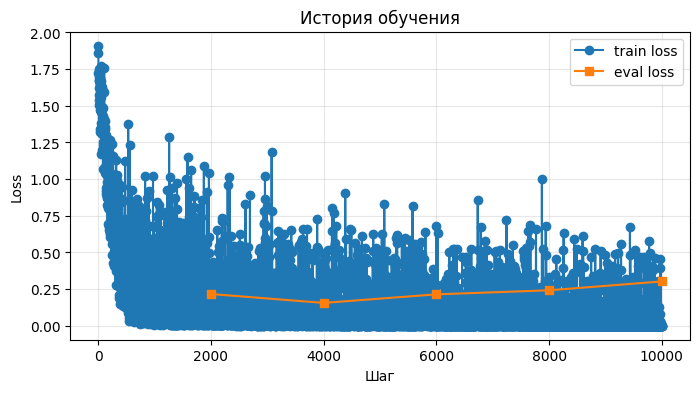

In [ ]:

history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("artifacts/figures/training_curves.png")
plt.show()


In [ ]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

/Users/ruslanhincagov/Desktop/aie-group3/aie-gr3-stud-repos/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/ruslanhincagov/Desktop/aie-group3/aie-gr3-stud-repos/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Validation metrics:
eval_loss: 0.2140
eval_accuracy: 0.9395
eval_f1_macro: 0.9167
eval_f1_weighted: 0.9397
eval_runtime: 11.8141
eval_samples_per_second: 169.2890
eval_steps_per_second: 21.1610
epoch: 5.0000

Test metrics:
eval_loss: 0.2209
eval_accuracy: 0.9260
eval_f1_macro: 0.8848
eval_f1_weighted: 0.9261
eval_runtime: 10.6501
eval_samples_per_second: 187.7910
eval_steps_per_second: 23.4740
epoch: 5.0000


/Users/ruslanhincagov/Desktop/aie-group3/aie-gr3-stud-repos/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Classification report on test:
              precision    recall  f1-score   support

     sadness       0.97      0.96      0.96       581
         joy       0.95      0.95      0.95       695
        love       0.83      0.81      0.82       159
       anger       0.91      0.92      0.92       275
        fear       0.88      0.91      0.89       224
    surprise       0.76      0.77      0.77        66

    accuracy                           0.93      2000
   macro avg       0.88      0.89      0.88      2000
weighted avg       0.93      0.93      0.93      2000



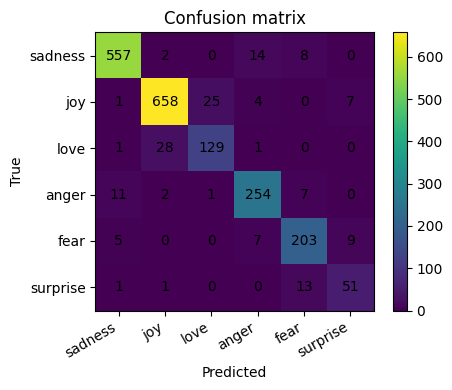

In [ ]:
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(list(id2label)))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("artifacts/figures/confusion_matrix.png")
plt.show()
